In [30]:
import os

print(os.getcwd())

c:\Users\shafi\number-simplex-reproduction\notebooks1


In [31]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(project_root)

c:\Users\shafi\number-simplex-reproduction


In [32]:
from src.lda_vs_logistic import compare_lda_logistic_neuron

In [7]:
out = compare_lda_logistic_neuron(
    subject="YFU",
    neuron=43,
    n_shuffles=200,
    verbose=True,
)

c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\sha


YFU neuron 43
Region: hpc

LDA
--------------------------------------------
Best bin: 150 ms
Best gamma: 0.2
Accuracy: 16.40%
Permutation null mean: 11.19%
Permutation p: 0.0100
Coding: True

LOGISTIC REGRESSION
--------------------------------------------
Best bin: 150 ms
Accuracy: 15.99%
Permutation null mean: 12.29%
Permutation p: 0.0100
Coding: True

DIFFERENCE
--------------------------------------------
Logistic - LDA: -0.40 percentage points


c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\shafi\number-simplex-reproduction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\sha

In [10]:
import pandas as pd

result = pd.DataFrame(
    [out["summary"]]
)

result

,subject,neuron,region,lda_best_bin_ms,lda_best_gamma,lda_accuracy,lda_accuracy_percent,lda_null_mean_percent,lda_p_value,lda_coding,logistic_best_bin_ms,logistic_accuracy,logistic_accuracy_percent,logistic_null_mean_percent,logistic_p_value,logistic_coding
0,YFU,43,hpc,150,0.2,0.163968,16.396761,11.194332,0.00995,True,150,0.159919,15.991903,12.288462,0.00995,True


In [11]:
out["lda_grid"]

,bin_size_ms,n_bins,gamma,pooled_cv_accuracy,accuracy_percent
0,150,6,0.2,0.163968,16.396761
1,150,6,0.5,0.161943,16.194332
2,150,6,0.8,0.159919,15.991903
3,180,5,0.2,0.139676,13.967611
4,180,5,0.5,0.139676,13.967611
5,75,12,0.2,0.137652,13.765182
6,75,12,0.5,0.135628,13.562753
7,180,5,0.8,0.131579,13.157895
8,60,15,0.5,0.125506,12.550607
9,60,15,0.8,0.125506,12.550607


In [12]:
out["logistic_grid"]



,bin_size_ms,n_bins,pooled_cv_accuracy,accuracy_percent
0,150,6,0.159919,15.991903
1,900,1,0.137652,13.765182
2,450,2,0.133603,13.360324
3,75,12,0.131579,13.157895
4,100,9,0.129555,12.955466
5,60,15,0.127530,12.753036
6,300,3,0.121457,12.145749
7,180,5,0.109312,10.931174
8,90,10,0.103239,10.323887
9,225,4,0.103239,10.323887


In [13]:
import pandas as pd

result = pd.DataFrame(
    [out["summary"]]
)

result.T

,0
subject,YFU
neuron,43
region,hpc
lda_best_bin_ms,150
lda_best_gamma,0.2
lda_accuracy,0.163968
lda_accuracy_percent,16.396761
lda_null_mean_percent,11.194332
lda_p_value,0.00995
lda_coding,True


In [14]:
from pathlib import Path

table_dir = Path("../tables1")
table_dir.mkdir(parents=True, exist_ok=True)

result.to_csv(
    table_dir / "YFU_neuron43_lda_vs_logistic.csv",
    index=False,
)

print("Saved!")

Saved!


In [16]:
from src import firing_rate_tuning

print([
    name for name in dir(firing_rate_tuning)
    if "neuron" in name.lower()
    or "subject" in name.lower()
])

['analyze_neuron']


In [17]:
import inspect
from src import firing_rate_tuning

print(inspect.getsource(firing_rate_tuning.analyze_neuron))

def analyze_neuron(
    subject,
    neuron,
    root=None,
    plot=True,
    verbose=True,
):
    """
    Compute arithmetic-task firing-rate tuning for one neuron.

    Parameters
    ----------
    subject : str
        Subject ID, e.g. "YFU".

    neuron : int
        MATLAB/paper neuron row number.
        Example: YFU.hpc.43 -> neuron=43.
        Internally converted to Python row 42.

    root : str or Path, optional
        Root directory of the repository.
        If None, assumes the current working directory is a notebook
        inside notebooks1/.

    plot : bool
        Whether to plot the mean firing-rate tuning curve.

    verbose : bool
        Whether to print subject/neuron information.

    Returns
    -------
    dict
        Contains:
        - subject
        - matlab_row
        - python_row
        - region
        - total_neurons
        - region_counts
        - mtl_region_counts
        - presentations
        - tuning
        - spike_times
        - figur

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
from src.lda_vs_logistic import (
    compare_lda_logistic_subject
)

print("Subject function imported successfully.")

Subject function imported successfully.


import sys
from pathlib import Path

from src.lda_vs_logistic import compare_lda_logistic_subject


# Repository root
ROOT = Path(__file__).resolve().parent


if len(sys.argv) != 2:
    print(
        "Usage: python run_lda_vs_logistic_subject.py SUBJECT"
    )
    print(
        "Example: python run_lda_vs_logistic_subject.py YFF"
    )
    sys.exit(1)


subject = sys.argv[1].upper()

valid_subjects = {
    "YFF", "YFI", "YFJ", "YFK", "YFL",
    "YFM", "YFP", "YFR", "YFS", "YFT", "YFU",
}

if subject not in valid_subjects:
    raise ValueError(
        f"Unknown subject: {subject}"
    )


print("=" * 60)
print("LDA vs Logistic Regression")
print(f"Starting subject: {subject}")
print("=" * 60)


results = compare_lda_logistic_subject(
    subject=subject,
    root=ROOT,
    output_dir=ROOT / "tables1",
    n_splits=10,
    n_shuffles=200,
    random_state=42,
    shuffle_seed=12345,
    mtl_only=True,
)


print("\nDone.")
print(f"Subject: {subject}")
print(f"Analyzed neurons: {len(results)}")

In [3]:
import sys
from pathlib import Path

from src.lda_vs_logistic import compare_lda_logistic_subject


# Repository root
ROOT = Path(__file__).resolve().parent


if len(sys.argv) != 2:
    print(
        "Usage: python run_lda_vs_logistic_subject.py SUBJECT"
    )
    print(
        "Example: python run_lda_vs_logistic_subject.py YFF"
    )
    sys.exit(1)


subject = sys.argv[1].upper()

valid_subjects = {
    "YFF", "YFI", "YFJ", "YFK", "YFL",
    "YFM", "YFP", "YFR", "YFS", "YFT", "YFU",
}

if subject not in valid_subjects:
    raise ValueError(
        f"Unknown subject: {subject}"
    )


print("=" * 60)
print("LDA vs Logistic Regression")
print(f"Starting subject: {subject}")
print("=" * 60)


results = compare_lda_logistic_subject(
    subject=subject,
    root=ROOT,
    output_dir=ROOT / "tables1",
    n_splits=10,
    n_shuffles=200,
    random_state=42,
    shuffle_seed=12345,
    mtl_only=True,
)


print("\nDone.")
print(f"Subject: {subject}")
print(f"Analyzed neurons: {len(results)}")

NameError: name '__file__' is not defined

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TABLES_DIR = Path("../tables1")

subjects = [
    "YFF", "YFI", "YFJ", "YFK", "YFL", "YFM",
    "YFP", "YFR", "YFS", "YFT", "YFU"
]

dfs = []

for subject in subjects:
    df_subject = pd.read_csv(
        TABLES_DIR / f"{subject}_lda_vs_logistic.csv"
    )
    dfs.append(df_subject)

df = pd.concat(dfs, ignore_index=True)

print("Subjects:", df["subject"].nunique())
print("Total neurons:", len(df))

df.head()

Subjects: 11
Total neurons: 466


,subject,neuron,region,lda_best_bin_ms,lda_best_gamma,lda_accuracy,lda_accuracy_percent,lda_null_mean_percent,lda_p_value,lda_coding,logistic_best_bin_ms,logistic_accuracy,logistic_accuracy_percent,logistic_null_mean_percent,logistic_p_value,logistic_coding
0,YFF,10,hpc,450,0.2,0.165138,16.513761,10.830275,0.099502,False,90,0.165138,16.513761,12.275229,0.164179,False
1,YFF,11,hpc,75,0.8,0.165138,16.513761,11.472477,0.084577,False,75,0.174312,17.431193,12.288991,0.079602,False
2,YFF,12,hpc,450,0.2,0.155963,15.596330,11.009174,0.109453,False,300,0.165138,16.513761,12.779817,0.169154,False
3,YFF,13,hpc,90,0.2,0.146789,14.678899,10.963303,0.164179,False,225,0.174312,17.431193,12.385321,0.094527,False
4,YFF,14,hpc,225,0.2,0.192661,19.266055,11.316514,0.039801,True,900,0.183486,18.348624,14.064220,0.144279,False


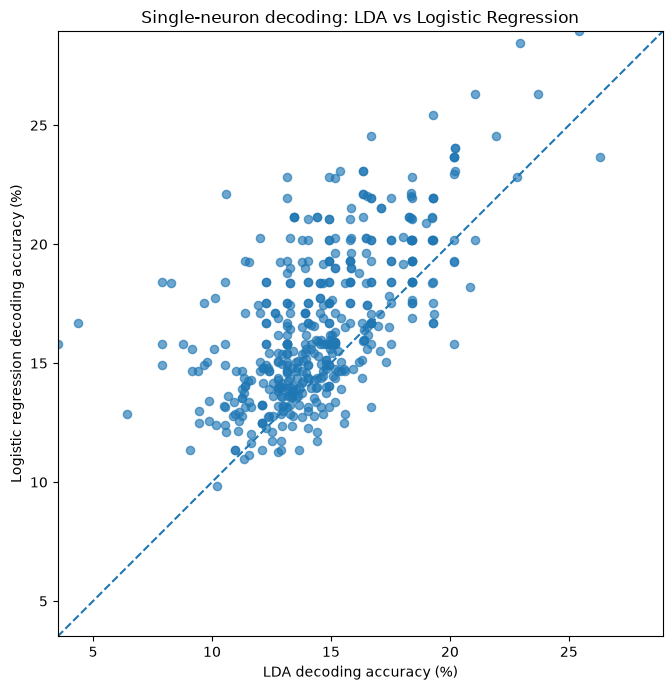

In [2]:
x = df["lda_accuracy_percent"]
y = df["logistic_accuracy_percent"]

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    x,
    y,
    alpha=0.65,
    s=35
)

# Same limits for both axes
low = min(x.min(), y.min())
high = max(x.max(), y.max())

# y = x reference line
ax.plot(
    [low, high],
    [low, high],
    linestyle="--",
    linewidth=1.5
)

ax.set_xlim(low, high)
ax.set_ylim(low, high)

ax.set_xlabel("LDA decoding accuracy (%)")
ax.set_ylabel("Logistic regression decoding accuracy (%)")
ax.set_title("Single-neuron decoding: LDA vs Logistic Regression")

ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

In [3]:
df["accuracy_difference"] = (
    df["logistic_accuracy_percent"]
    - df["lda_accuracy_percent"]
)

n_logistic_better = (df["accuracy_difference"] > 0).sum()
n_lda_better = (df["accuracy_difference"] < 0).sum()
n_tied = (np.isclose(df["accuracy_difference"], 0)).sum()

print("Total neurons:", len(df))
print()
print("Logistic better:", n_logistic_better)
print("LDA better:     ", n_lda_better)
print("Tied:           ", n_tied)

print()
print(
    "Logistic better (%):",
    100 * n_logistic_better / len(df)
)
print(
    "LDA better (%):",
    100 * n_lda_better / len(df)
)

print()
print(
    "Mean Logistic - LDA difference:",
    df["accuracy_difference"].mean()
)
print(
    "Median Logistic - LDA difference:",
    df["accuracy_difference"].median()
)

Total neurons: 466

Logistic better: 356
LDA better:      80
Tied:            30

Logistic better (%): 76.39484978540773
LDA better (%): 17.167381974248926

Mean Logistic - LDA difference: 2.099312207232075
Median Logistic - LDA difference: 1.7543859649122808


| Outcome | Neurons | Percentage |
|---|---:|---:|
| Logistic higher accuracy | **356** | **76.4%** |
| LDA higher accuracy | 80 | 17.2% |
| Exact tie | 30 | 6.4% |

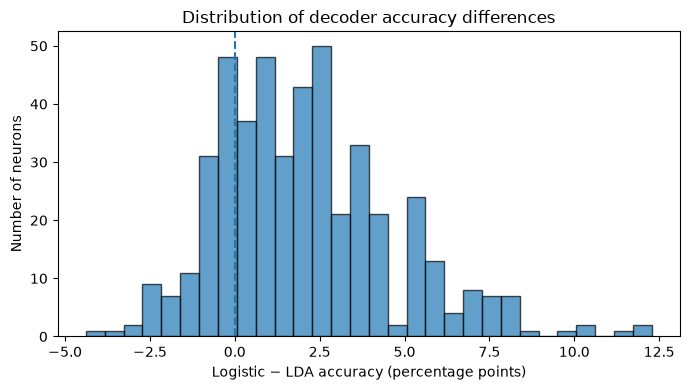

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(
    df["accuracy_difference"],
    bins=30,
    edgecolor="black",
    alpha=0.7
)

ax.axvline(0, linestyle="--", linewidth=1.5)

ax.set_xlabel("Logistic − LDA accuracy (percentage points)")
ax.set_ylabel("Number of neurons")
ax.set_title("Distribution of decoder accuracy differences")

plt.tight_layout()
plt.show()

In [6]:
subject_summary = (
    df.groupby("subject")
    .agg(
        n_neurons=("neuron", "size"),
        lda_mean=("lda_accuracy_percent", "mean"),
        logistic_mean=("logistic_accuracy_percent", "mean"),
        mean_difference=("accuracy_difference", "mean"),
        median_difference=("accuracy_difference", "median"),
    )
)

# Classify each neuron
df["winner"] = np.select(
    [
        df["accuracy_difference"] > 0,
        df["accuracy_difference"] < 0,
    ],
    [
        "Logistic",
        "LDA",
    ],
    default="Tie",
)

winner_counts = (
    pd.crosstab(df["subject"], df["winner"])
    .reindex(columns=["Logistic", "LDA", "Tie"], fill_value=0)
)

subject_summary = subject_summary.join(winner_counts)

subject_summary.round(2)

,n_neurons,lda_mean,logistic_mean,mean_difference,median_difference,Logistic,LDA,Tie
subject,,,,,,,,
YFF,36,15.27,17.86,2.60,2.75,26,7,3
YFI,21,16.35,21.75,5.40,5.77,21,0,0
YFJ,45,15.67,18.87,3.20,3.51,37,6,2
YFK,26,16.63,19.43,2.80,2.63,20,3,3
YFL,42,15.27,17.77,2.51,2.63,33,4,5
YFM,32,15.05,17.76,2.71,2.19,23,5,4
YFP,43,14.66,18.71,4.05,3.80,43,0,0
YFR,65,13.55,15.08,1.53,1.50,50,11,4
YFS,59,13.83,13.82,-0.01,0.38,30,24,5


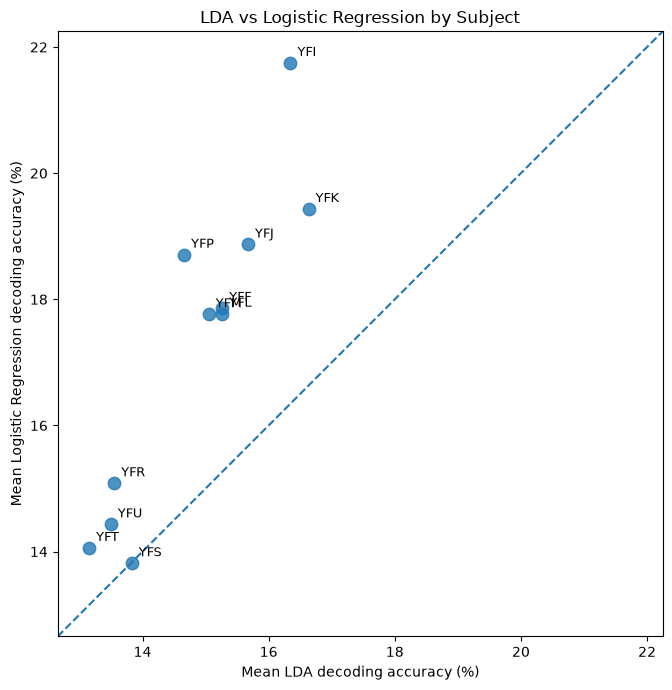

In [7]:
# Subject-level scatter plot

x = subject_summary["lda_mean"]
y = subject_summary["logistic_mean"]

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    x,
    y,
    s=80,
    alpha=0.8
)

# Label each subject
for subject in subject_summary.index:
    ax.annotate(
        subject,
        (
            subject_summary.loc[subject, "lda_mean"],
            subject_summary.loc[subject, "logistic_mean"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

# Same limits for x and y
low = min(x.min(), y.min()) - 0.5
high = max(x.max(), y.max()) + 0.5

ax.plot(
    [low, high],
    [low, high],
    linestyle="--",
    linewidth=1.5
)

ax.set_xlim(low, high)
ax.set_ylim(low, high)

ax.set_xlabel("Mean LDA decoding accuracy (%)")
ax.set_ylabel("Mean Logistic Regression decoding accuracy (%)")
ax.set_title("LDA vs Logistic Regression by Subject")

ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

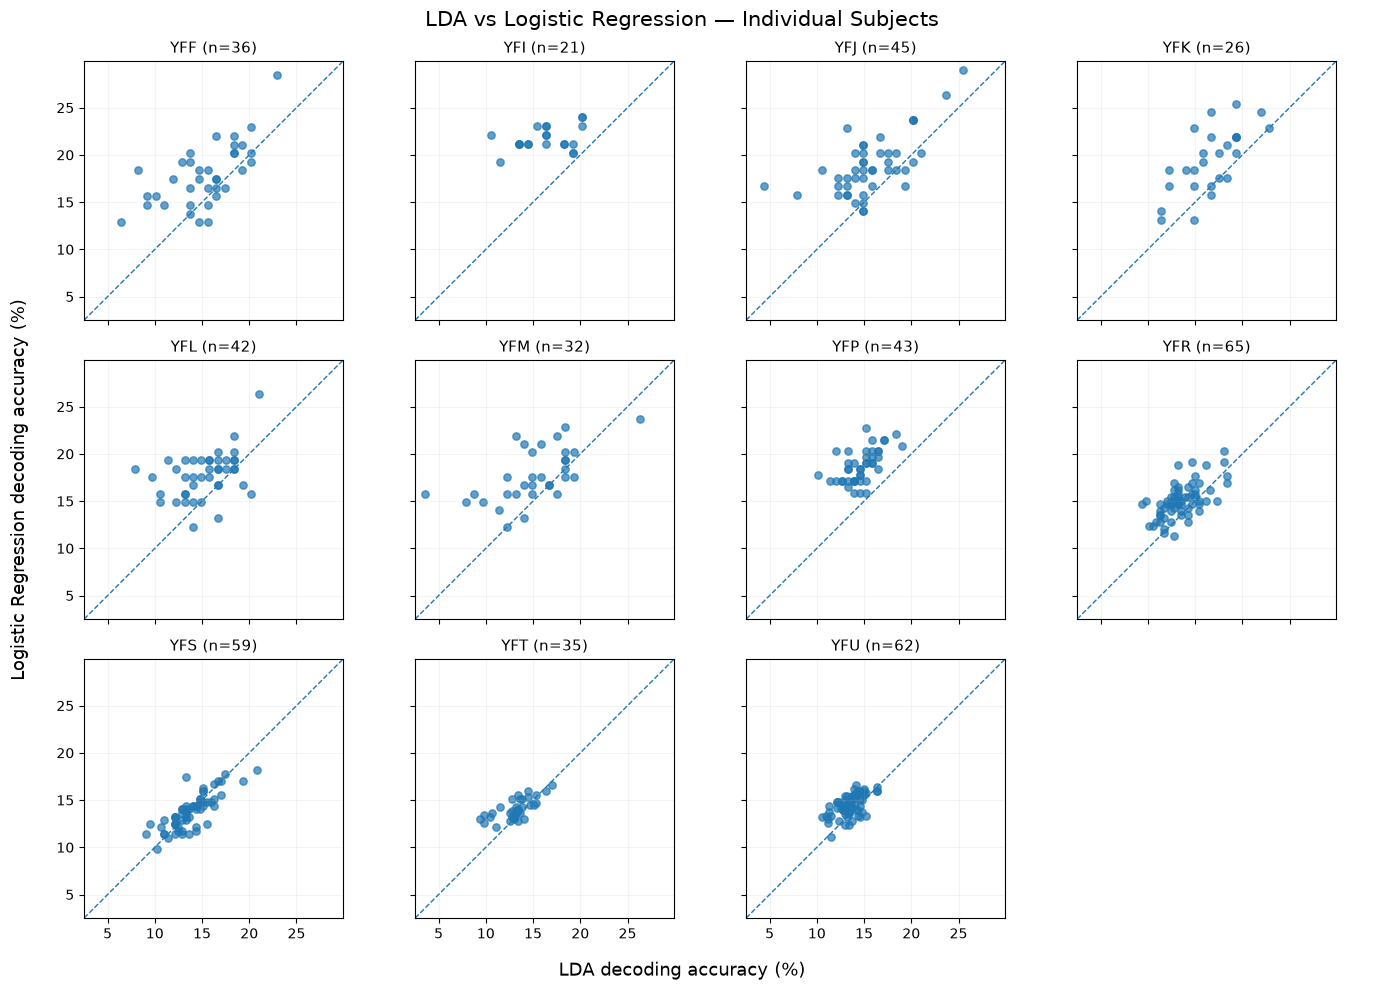

In [8]:
# 11 subject-specific LDA vs Logistic scatter plots

fig, axes = plt.subplots(
    3, 4,
    figsize=(14, 10),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

# Common limits across ALL subjects
all_x = df["lda_accuracy_percent"]
all_y = df["logistic_accuracy_percent"]

low = min(all_x.min(), all_y.min()) - 1
high = max(all_x.max(), all_y.max()) + 1

for ax, subject in zip(axes, subjects):

    d = df[df["subject"] == subject]

    x = d["lda_accuracy_percent"]
    y = d["logistic_accuracy_percent"]

    ax.scatter(
        x,
        y,
        s=28,
        alpha=0.7
    )

    # y = x
    ax.plot(
        [low, high],
        [low, high],
        linestyle="--",
        linewidth=1
    )

    ax.set_xlim(low, high)
    ax.set_ylim(low, high)

    ax.set_title(
        f"{subject} (n={len(d)})",
        fontsize=11
    )

    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.15)


# Remove unused 12th panel
axes[-1].axis("off")


# Shared axis labels
fig.supxlabel("LDA decoding accuracy (%)", fontsize=13)
fig.supylabel("Logistic Regression decoding accuracy (%)", fontsize=13)

fig.suptitle(
    "LDA vs Logistic Regression — Individual Subjects",
    fontsize=15,
    y=0.98
)

plt.tight_layout()
plt.show()

In [9]:
subject_results = []

for subject in subjects:
    d = df[df["subject"] == subject].copy()

    diff = (
        d["logistic_accuracy_percent"]
        - d["lda_accuracy_percent"]
    )

    subject_results.append({
        "subject": subject,
        "n": len(d),

        "LDA mean (%)":
            d["lda_accuracy_percent"].mean(),

        "Logistic mean (%)":
            d["logistic_accuracy_percent"].mean(),

        "Logistic - LDA (pp)":
            diff.mean(),

        "Logistic better":
            (diff > 0).sum(),

        "LDA better":
            (diff < 0).sum(),

        "Tie":
            np.isclose(diff, 0).sum(),

        "Logistic better (%)":
            100 * (diff > 0).sum() / len(d)
    })

subject_results = pd.DataFrame(subject_results)

subject_results.round(2)

,subject,n,LDA mean (%),Logistic mean (%),Logistic - LDA (pp),Logistic better,LDA better,Tie,Logistic better (%)
0,YFF,36,15.27,17.86,2.60,26,7,3,72.22
1,YFI,21,16.35,21.75,5.40,21,0,0,100.00
2,YFJ,45,15.67,18.87,3.20,37,6,2,82.22
3,YFK,26,16.63,19.43,2.80,20,3,3,76.92
4,YFL,42,15.27,17.77,2.51,33,4,5,78.57
5,YFM,32,15.05,17.76,2.71,23,5,4,71.88
6,YFP,43,14.66,18.71,4.05,43,0,0,100.00
7,YFR,65,13.55,15.08,1.53,50,11,4,76.92
8,YFS,59,13.83,13.82,-0.01,30,24,5,50.85
9,YFT,35,13.15,14.06,0.90,26,7,2,74.29


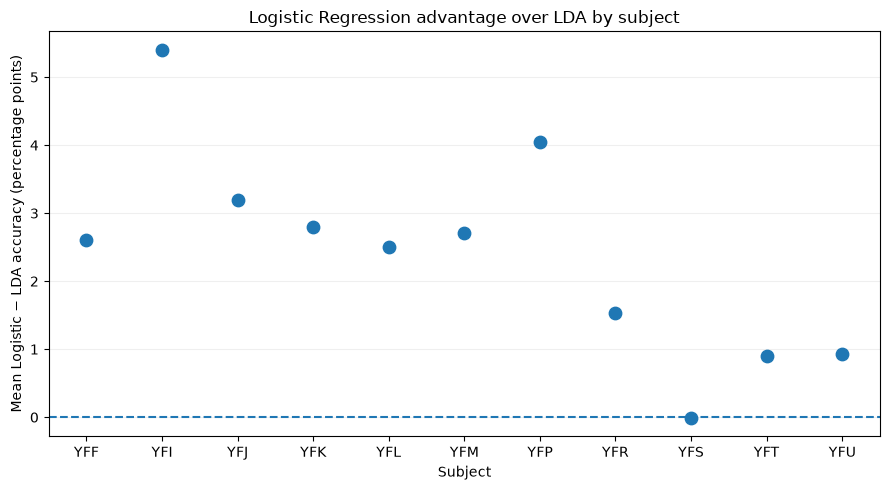

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(subject_results))
y = subject_results["Logistic - LDA (pp)"]

ax.scatter(
    x,
    y,
    s=80,
    zorder=3
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.5
)

ax.set_xticks(x)
ax.set_xticklabels(subject_results["subject"])

ax.set_ylabel("Mean Logistic − LDA accuracy (percentage points)")
ax.set_xlabel("Subject")

ax.set_title(
    "Logistic Regression advantage over LDA by subject"
)

ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

In [11]:
coding_summary = []

for subject in subjects:
    d = df[df["subject"] == subject]

    n = len(d)

    lda_coding = d["lda_coding"].astype(bool)
    log_coding = d["logistic_coding"].astype(bool)

    both = lda_coding & log_coding
    lda_only = lda_coding & ~log_coding
    log_only = ~lda_coding & log_coding
    neither = ~lda_coding & ~log_coding

    coding_summary.append({
        "Subject": subject,
        "N": n,

        "LDA coding": lda_coding.sum(),
        "LDA coding (%)": 100 * lda_coding.mean(),

        "Logistic coding": log_coding.sum(),
        "Logistic coding (%)": 100 * log_coding.mean(),

        "Both": both.sum(),
        "LDA only": lda_only.sum(),
        "Logistic only": log_only.sum(),
        "Neither": neither.sum()
    })


# -------------------------
# ALL SUBJECTS
# -------------------------

lda_coding = df["lda_coding"].astype(bool)
log_coding = df["logistic_coding"].astype(bool)

coding_summary.append({
    "Subject": "ALL",
    "N": len(df),

    "LDA coding": lda_coding.sum(),
    "LDA coding (%)": 100 * lda_coding.mean(),

    "Logistic coding": log_coding.sum(),
    "Logistic coding (%)": 100 * log_coding.mean(),

    "Both": (lda_coding & log_coding).sum(),
    "LDA only": (lda_coding & ~log_coding).sum(),
    "Logistic only": (~lda_coding & log_coding).sum(),
    "Neither": (~lda_coding & ~log_coding).sum()
})

coding_summary = pd.DataFrame(coding_summary)

coding_summary.round(2)

,Subject,N,LDA coding,LDA coding (%),Logistic coding,Logistic coding (%),Both,LDA only,Logistic only,Neither
0,YFF,36,11,30.56,10,27.78,8,3,2,23
1,YFI,21,8,38.10,2,9.52,1,7,1,12
2,YFJ,45,13,28.89,13,28.89,8,5,5,27
3,YFK,26,10,38.46,11,42.31,8,2,3,13
4,YFL,42,8,19.05,4,9.52,2,6,2,32
5,YFM,32,9,28.12,7,21.88,3,6,4,19
6,YFP,43,6,13.95,10,23.26,4,2,6,31
7,YFR,65,16,24.62,13,20.00,8,8,5,44
8,YFS,59,16,27.12,11,18.64,10,6,1,42
9,YFT,35,9,25.71,11,31.43,6,3,5,21


| Classification | Neurons | % of all neurons |
|---|---:|---:|
| LDA number-coding | **132** | **28.33%** |
| Logistic number-coding | **108** | **23.18%** |
| Coding with both | **74** | **15.88%** |
| LDA only | **58** | **12.45%** |
| Logistic only | **34** | **7.30%** |
| Neither | **300** | **64.38%** |

In [13]:
from pathlib import Path

code = Path("../src/lda_vs_logistic.py").read_text()

print(code)

"""
lda_vs_logistic.py

Compare single-neuron temporal number decoding using:

    1. Linear Discriminant Analysis (LDA)
    2. Multinomial Logistic Regression

Current analysis strategy
-------------------------
For LDA:
    - Search bin size x LDA shrinkage gamma
    - Select best combination using real-label CV accuracy
    - Keep best bin size and gamma fixed
    - Run 200 label-shuffle permutations

For Logistic Regression:
    - Search temporal bin size
    - Select best bin size using real-label CV accuracy
    - Keep best bin size fixed
    - Run 200 label-shuffle permutations

IMPORTANT
---------
This intentionally reproduces the CURRENT permutation philosophy.

The bin size / hyperparameters are NOT re-selected separately
inside every permutation.

A stricter nested permutation procedure can be implemented later.
"""


# ============================================================
# IMPORTS
# ============================================================

import numpy as np
imp

In [14]:
master = pd.read_csv("../tables1/figure1M_all_neuron_permutations.csv")

print(master["region"].value_counts(dropna=False))

region
hpc         387
amy          77
ent          70
para-hpc     18
Name: count, dtype: int64


In [15]:
# Which subjects contain ENT and para-HPC neurons?

region_subjects = (
    master[
        master["region"].isin(["ent", "para-hpc"])
    ]
    .groupby(["subject", "region"])
    .size()
    .unstack(fill_value=0)
)

region_subjects["total_to_add"] = region_subjects.sum(axis=1)

region_subjects

region,ent,para-hpc,total_to_add
subject,,,
YFF,1,0,1
YFI,8,0,8
YFK,0,18,18
YFL,15,0,15
YFM,29,0,29
YFT,17,0,17
